# Comparing NeqSim Expander / Compressor ModelsThis notebook builds and compares **all the expander- and compressor-related unit operations in NeqSim**,with a focus on the single-shaft **turboexpander-compressor (companding) machine** used in NGL/LNG plants.The integrated machine is conceptually equivalent to the Atlas Copco Mafi-Trench / River City Engineering**EC-OD™** off-design rating utility for Aspen HYSYS, but built on open NeqSim classes.## Models covered| # | Model | Class | Off-design basis ||---|-------|-------|------------------|| 1 | Stand-alone expander | `Expander` | isentropic efficiency || 2 | Stand-alone compressor (map) | `Compressor` + `CompressorChart` | performance map (head/eff vs flow & speed) || 3 | Mach-corrected compressor map | `CompressorChartKhader2015` | dimensionless Mach-number map (composition aware) || 4 | Turboexpander-compressor (curve-fit) | `TurboExpanderCompressor` | bespoke U/C & Q/N correction factors + IGV || 5 | Turboexpander-compressor (map) | `MapTurboExpanderCompressor` | reuses compressor map + shaft power balance |## What we compare- Expander power, outlet temperature, isentropic efficiency- Compressor power, head, polytropic efficiency, discharge pressure- **Single-shaft power balance** and the solved common shaft speed- How models 4 and 5 differ in handling **off-design** operation

## 1. Setup — load NeqSim from the local buildThese models (`TurboExpanderCompressor`, `MapTurboExpanderCompressor`) are loaded directly from theproject's compiled classes via the dev setup, so any local Java change is immediately available.A pip fallback is included for Colab / non-dev environments.

In [1]:
import subprocess, sys

try:
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(recompile=False)
    ns = neqsim_classes(ns)
    import jpype
    JClass = jpype.JClass
    NEQSIM_MODE = "devtools"
    print("NeqSim loaded via devtools (local dev mode)")
except ImportError:
    try:
        import neqsim
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "neqsim"])
    from neqsim import jneqsim
    import jpype
    JClass = jpype.JClass
    NEQSIM_MODE = "pip"
    print("NeqSim loaded via pip package")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim2
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim2\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim2\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim2\target\neqsim-3.10.0.jar



JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim loaded via devtools (local dev mode)


In [2]:
# Resolve the Java classes we need (works in both dev and pip modes)
def jc(path):
    return JClass(path)

SystemSrkEos = jc("neqsim.thermo.system.SystemSrkEos")
Stream = jc("neqsim.process.equipment.stream.Stream")
Expander = jc("neqsim.process.equipment.expander.Expander")
Compressor = jc("neqsim.process.equipment.compressor.Compressor")
CompressorChartKhader2015 = jc("neqsim.process.equipment.compressor.CompressorChartKhader2015")
TurboExpanderCompressor = jc("neqsim.process.equipment.expander.TurboExpanderCompressor")
MapTurboExpanderCompressor = jc("neqsim.process.equipment.expander.MapTurboExpanderCompressor")
ShaftMode = jc("neqsim.process.equipment.expander.MapTurboExpanderCompressor$ShaftMode")
UUID = jc("java.util.UUID")

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("Classes imported.")

Classes imported.


## 2. Define the process gasA typical lean natural gas. We create two feed streams:- **Expander feed** — high-pressure cold gas that is let down across the expander (produces shaft power).- **Compressor feed** — lower-pressure residue gas that the brake compressor boosts using the recovered power.

In [3]:
def make_gas(temperature_C, pressure_bara):
    fluid = SystemSrkEos(273.15 + temperature_C, pressure_bara)
    fluid.addComponent("nitrogen", 0.006)
    fluid.addComponent("CO2", 0.014)
    fluid.addComponent("methane", 0.862)
    fluid.addComponent("ethane", 0.08)
    fluid.addComponent("propane", 0.03)
    fluid.addComponent("i-butane", 0.0024)
    fluid.addComponent("n-butane", 0.004)
    fluid.addComponent("n-hexane", 0.0015)
    fluid.setMixingRule(2)
    fluid.setTemperature(temperature_C, "C")
    fluid.setPressure(pressure_bara, "bara")
    return fluid

# Expander feed: high pressure, cold
expander_feed = Stream("expander feed", make_gas(-23.0, 60.95))
expander_feed.setFlowRate(200000.0, "kg/hr")
expander_feed.run()

# Compressor feed: lower pressure, warmer
compressor_feed = Stream("compressor feed", make_gas(17.0, 42.0))
compressor_feed.setFlowRate(130000.0, "kg/hr")
compressor_feed.run()

print("Expander feed : %.0f kg/hr, %.1f C, %.1f bara" % (
    expander_feed.getFlowRate("kg/hr"),
    expander_feed.getTemperature("C"),
    expander_feed.getPressure("bara")))
print("Compressor feed: %.0f kg/hr, %.1f C, %.1f bara" % (
    compressor_feed.getFlowRate("kg/hr"),
    compressor_feed.getTemperature("C"),
    compressor_feed.getPressure("bara")))

Expander feed : 200000 kg/hr, -23.0 C, 61.0 bara
Compressor feed: 130000 kg/hr, 17.0 C, 42.0 bara


## 3. Model 1 — stand-alone expanderThe simplest device: a fixed isentropic efficiency turbine. It produces shaft power and a cold outletstream but knows nothing about a coupled compressor.

In [4]:
exp = Expander("expander", expander_feed.clone())
exp.setOutletPressure(42.0)
exp.setIsentropicEfficiency(0.85)
exp.run()

print("Expander power        : %.3f MW" % exp.getPower("MW"))
print("Expander outlet temp  : %.2f C" % exp.getOutletStream().getTemperature("C"))
print("Isentropic efficiency : %.3f" % exp.getIsentropicEfficiency())

Expander power        : -1.340 MW
Expander outlet temp  : -40.90 C
Isentropic efficiency : 0.850


## 4. Models 2 & 3 — stand-alone compressor with a performance mapThe brake compressor side. We attach a multi-speed performance map. Using`CompressorChartKhader2015` makes the map **composition aware** (it works in a dimensionless,machine-Mach-number space), which is the closest NeqSim analogue to EC-OD's rigorous rating method.

In [5]:
# Multi-speed compressor map (speed [rpm], flow [m3/hr], head [kJ/kg], polytropic eff [%])
chart_conditions = [25.0, 50.0, 50.0, 20.0]  # T[C], P[bara], rho, MW (reference)
speed = [12913, 12298, 11683, 11098, 10453, 9224, 8609, 8200]
flow = [
    [2789.1, 3174.0, 3689.2, 4179.5, 4570.3, 4954.8, 5246.0, 5661.0],
    [2571.2, 2943.7, 3440.3, 3837.4, 4253.1, 4668.7, 4997.2, 5387.5],
    [2415.4, 2763.1, 3141.7, 3594.7, 4047.6, 4494.2, 4853.7, 5138.8],
    [2247.2, 2799.7, 3178.3, 3656.2, 4102.8, 4394.2, 4648.3, 4840.5],
    [2072.8, 2463.9, 2836.4, 3202.5, 3599.6, 3978.0, 4257.0, 4517.3],
    [1836.0, 2208.5, 2618.1, 2940.8, 3244.8, 3530.1, 3753.4, 3896.0],
    [1711.3, 1965.9, 2356.9, 2685.9, 3008.5, 3337.3, 3591.5, 3720.0],
    [1636.6, 2002.9, 2338.0, 2642.1, 2896.5, 3113.6, 3274.9, 3411.3],
]
head = [
    [80.04, 78.89, 76.21, 71.87, 67.01, 60.61, 53.05, 39.73],
    [72.21, 71.84, 68.90, 65.83, 60.72, 54.70, 47.27, 35.75],
    [65.16, 64.53, 62.61, 59.16, 54.05, 47.01, 39.20, 31.64],
    [58.62, 56.96, 54.66, 50.45, 44.43, 38.41, 32.91, 28.81],
    [52.33, 51.06, 49.53, 46.33, 42.37, 37.25, 31.49, 25.60],
    [40.66, 39.64, 37.60, 34.66, 30.95, 27.11, 23.27, 20.45],
    [35.27, 34.64, 32.72, 31.06, 27.10, 22.75, 18.01, 18.01],
    [32.19, 31.18, 29.13, 26.83, 23.89, 21.33, 18.77, 16.34],
]
poly_eff = [
    [77.2, 79.4, 80.7, 80.5, 79.2, 75.5, 69.6, 58.7],
    [77.0, 79.3, 80.9, 80.7, 79.5, 75.6, 69.7, 60.0],
    [77.0, 79.2, 80.8, 80.7, 78.9, 73.7, 66.3, 57.7],
    [77.1, 80.5, 81.1, 79.6, 75.4, 69.5, 63.8, 58.8],
    [77.0, 79.8, 80.9, 80.6, 78.0, 73.0, 66.6, 59.9],
    [77.5, 80.2, 81.0, 79.6, 76.4, 70.8, 64.6, 60.5],
    [77.8, 80.1, 81.1, 79.9, 76.2, 69.3, 60.9, 60.9],
    [78.1, 80.9, 80.8, 78.9, 75.2, 70.3, 65.6, 61.0],
]

def to_java_2d(rows):
    return jpype.JArray(jpype.JDouble, 2)([jpype.JArray(jpype.JDouble)(r) for r in rows])

def to_java_1d(vals):
    return jpype.JArray(jpype.JDouble)(vals)

print("Map data prepared:", len(speed), "speed lines.")

Map data prepared: 8 speed lines.


In [6]:
comp = Compressor("compressor", compressor_feed.clone())
comp.setUsePolytropicCalc(True)
chart = CompressorChartKhader2015(comp.getInletStream(), 0.9)
chart.setCurves(to_java_1d(chart_conditions), to_java_1d(speed),
                to_java_2d(flow), to_java_2d(head), to_java_2d(flow), to_java_2d(poly_eff))
comp.setCompressorChart(chart)
comp.getCompressorChart().setHeadUnit("kJ/kg")
comp.setSpeed(11000)
comp.run()

print("Compressor speed      : %.0f rpm" % comp.getSpeed())
print("Compressor power      : %.3f MW" % comp.getPower("MW"))
print("Polytropic head       : %.2f kJ/kg" % comp.getPolytropicHead("kJ/kg"))
print("Polytropic efficiency : %.1f %%" % (comp.getPolytropicEfficiency() * 100))
print("Discharge pressure    : %.2f bara" % comp.getOutletStream().getPressure("bara"))

Compressor speed      : 11000 rpm
Compressor power      : 2.149 MW
Polytropic head       : 47.52 kJ/kg
Polytropic efficiency : 79.9 %
Discharge pressure    : 62.51 bara


## 5. Model 4 — `TurboExpanderCompressor` (curve-fit / IGV)The existing integrated single-shaft machine. It uses **bespoke U/C and Q/N correction curves** plus anIGV (inlet guide vane) model, mirroring the variables exposed by the EC-OD utility (U/C ratio, % Design Q/N,IGV position). The shaft speed is solved by matching expander and compressor power.

In [7]:
tec = TurboExpanderCompressor("TEC-curvefit", expander_feed.clone())
tec.setCompressorFeedStream(compressor_feed.clone())

# Off-design correction curves (vendor / test data)
tec.setUCcurve(
    to_java_1d([0.99648, 0.75908, 0.98430, 0.88278, 0.95525, 1.0]),
    to_java_1d([0.98409, 0.79659, 0.99318, 0.93636, 0.99432, 1.0]))
tec.setQNEfficiencycurve(
    to_java_1d([0.5, 0.7, 0.85, 1.0, 1.2, 1.4, 1.6]),
    to_java_1d([0.88, 0.91, 0.95, 1.0, 0.97, 0.85, 0.6]))
tec.setQNHeadcurve(
    to_java_1d([0.5, 0.8, 1.0, 1.2, 1.4, 1.6]),
    to_java_1d([1.1, 1.05, 1.0, 0.9, 0.7, 0.4]))

# Design point
tec.setImpellerDiameter(0.424)          # m
tec.setDesignSpeed(6850.0)              # rpm
tec.setExpanderDesignIsentropicEfficiency(0.88)
tec.setDesignUC(0.7)
tec.setDesignQn(0.03328)
tec.setExpanderOutPressure(42.0)
tec.setCompressorDesignPolytropicEfficiency(0.81)
tec.setCompressorDesignPolytropicHead(20.47)  # kJ/kg
tec.setMaximumIGVArea(1.637e4)          # mm2
tec.run()

print("Solved shaft speed      : %.0f rpm" % tec.getSpeed())
print("Expander power          : %.3f MW" % tec.getPowerExpander("MW"))
print("Compressor power        : %.3f MW" % tec.getPowerCompressor("MW"))
print("Expander isentropic eff : %.3f" % tec.getExpanderIsentropicEfficiency())
print("Compressor poly eff     : %.3f" % tec.getCompressorPolytropicEfficiency())
print("Compressor poly head    : %.2f kJ/kg" % tec.getCompressorPolytropicHead())
print("U/C ratio (expander)    : %.3f" % tec.getUCratioexpander())
print("Q/N ratio (compressor)  : %.3f" % tec.getQNratiocompressor())
print("Expander outlet temp    : %.2f C" % tec.getExpanderOutletStream().getTemperature("C"))
print("Compressor discharge P  : %.2f bara" % tec.getCompressorOutletStream().getPressure("bara"))

Solved shaft speed      : 7229 rpm


Expander power          : 1.380 MW
Compressor power        : 1.380 MW
Expander isentropic eff : 0.876
Compressor poly eff     : 0.682
Compressor poly head    : 26.05 kJ/kg
U/C ratio (expander)    : 0.963
Q/N ratio (compressor)  : 0.244
Expander outlet temp    : -41.07 C


Compressor discharge P  : 52.42 bara


## 6. Model 5 — `MapTurboExpanderCompressor` (map-based)The new alternative. It couples a real `Expander` and a real `Compressor` on a common shaft, and reusesthe **compressor performance map** (here the composition-aware `CompressorChartKhader2015`) for thecompressor side. In **`BALANCED_SPEED`** mode the common shaft speed is solved so that compressor powerequals the shaft power delivered by the expander; the compressor discharge pressure is then an *output*.

In [8]:
mtec = MapTurboExpanderCompressor("TEC-map", expander_feed.clone(), compressor_feed.clone())
mtec.setExpanderOutletPressure(42.0)
mtec.setExpanderIsentropicEfficiency(0.85)
mtec.setMechanicalEfficiency(0.98)

# Attach the same composition-aware map to the compressor side
chart_m = CompressorChartKhader2015(mtec.getCompressor().getInletStream(), 0.9)
chart_m.setCurves(to_java_1d(chart_conditions), to_java_1d(speed),
                  to_java_2d(flow), to_java_2d(head), to_java_2d(flow), to_java_2d(poly_eff))
mtec.getCompressor().setCompressorChart(chart_m)
mtec.getCompressor().getCompressorChart().setHeadUnit("kJ/kg")
mtec.getCompressor().setUsePolytropicCalc(True)

mtec.setShaftMode(ShaftMode.BALANCED_SPEED)
mtec.run(UUID.randomUUID())

print("Solved shaft speed      : %.0f rpm" % mtec.getShaftSpeed())
print("Available shaft power   : %.3f MW" % (mtec.getAvailableShaftPower() / 1e6))
print("Compressor power        : %.3f MW" % (mtec.getConsumedCompressorPower() / 1e6))
print("Power balance residual  : %.2f kW" % (mtec.getPowerBalanceResidual() / 1e3))
print("Speed limited?          :", mtec.isSpeedLimited())
print("Expander outlet temp    : %.2f C" % mtec.getExpanderOutStream().getTemperature("C"))
print("Compressor discharge P  : %.2f bara" % mtec.getCompressorOutStream().getPressure("bara"))
print("Compressor poly eff     : %.1f %%" % (mtec.getCompressor().getPolytropicEfficiency() * 100))

Solved shaft speed      : 9199 rpm
Available shaft power   : 1.313 MW
Compressor power        : 1.313 MW
Power balance residual  : 0.00 kW
Speed limited?          : False
Expander outlet temp    : -40.90 C
Compressor discharge P  : 52.14 bara
Compressor poly eff     : 69.9 %


## 7. Side-by-side comparisonThe table collects the key results from each model. Note that models 1–3 are stand-alone components,while models 4 and 5 enforce the **single-shaft power balance** and therefore solve for a common speedand the compressor discharge pressure.

In [9]:
rows = []

rows.append({
    "Model": "1. Expander (standalone)",
    "Shaft speed [rpm]": np.nan,
    "Exp. power [MW]": abs(exp.getPower("MW")),
    "Comp. power [MW]": np.nan,
    "Exp. out T [C]": exp.getOutletStream().getTemperature("C"),
    "Comp. disch. P [bara]": np.nan,
    "Comp. poly eff [%]": np.nan,
    "Power balance": "n/a",
})
rows.append({
    "Model": "2/3. Compressor map (standalone)",
    "Shaft speed [rpm]": comp.getSpeed(),
    "Exp. power [MW]": np.nan,
    "Comp. power [MW]": comp.getPower("MW"),
    "Exp. out T [C]": np.nan,
    "Comp. disch. P [bara]": comp.getOutletStream().getPressure("bara"),
    "Comp. poly eff [%]": comp.getPolytropicEfficiency() * 100,
    "Power balance": "n/a",
})
rows.append({
    "Model": "4. TurboExpanderCompressor (curve-fit)",
    "Shaft speed [rpm]": tec.getSpeed(),
    "Exp. power [MW]": tec.getPowerExpander("MW"),
    "Comp. power [MW]": tec.getPowerCompressor("MW"),
    "Exp. out T [C]": tec.getExpanderOutletStream().getTemperature("C"),
    "Comp. disch. P [bara]": tec.getCompressorOutletStream().getPressure("bara"),
    "Comp. poly eff [%]": tec.getCompressorPolytropicEfficiency() * 100,
    "Power balance": "enforced",
})
rows.append({
    "Model": "5. MapTurboExpanderCompressor (map)",
    "Shaft speed [rpm]": mtec.getShaftSpeed(),
    "Exp. power [MW]": mtec.getAvailableShaftPower() / 1e6,
    "Comp. power [MW]": mtec.getConsumedCompressorPower() / 1e6,
    "Exp. out T [C]": mtec.getExpanderOutStream().getTemperature("C"),
    "Comp. disch. P [bara]": mtec.getCompressorOutStream().getPressure("bara"),
    "Comp. poly eff [%]": mtec.getCompressor().getPolytropicEfficiency() * 100,
    "Power balance": "enforced",
})

df = pd.DataFrame(rows).set_index("Model").round(2)
df

,Shaft speed [rpm],Exp. power [MW],Comp. power [MW],Exp. out T [C],Comp. disch. P [bara],Comp. poly eff [%],Power balance
Model,,,,,,,
1. Expander (standalone),NaN,1.34,NaN,-40.90,NaN,NaN,n/a
2/3. Compressor map (standalone),11000.00,NaN,2.15,NaN,62.51,79.86,n/a
4. TurboExpanderCompressor (curve-fit),7229.22,1.38,1.38,-41.07,52.42,68.17,enforced
5. MapTurboExpanderCompressor (map),9199.33,1.31,1.31,-40.90,52.14,69.86,enforced


## 8. Visual comparison — shaft power balanceFor the two integrated machines (models 4 and 5) the expander shaft power must equal the compressorabsorbed power. The bar chart shows how closely each model balances the shaft.

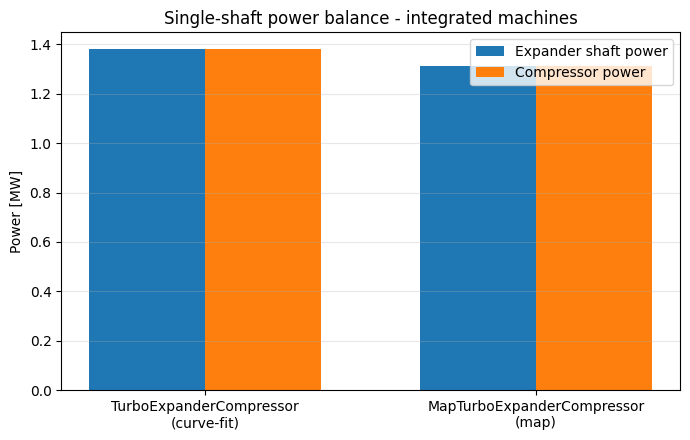

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["TurboExpanderCompressor\n(curve-fit)", "MapTurboExpanderCompressor\n(map)"]
exp_pow = [tec.getPowerExpander("MW"), mtec.getAvailableShaftPower() / 1e6]
comp_pow = [tec.getPowerCompressor("MW"), mtec.getConsumedCompressorPower() / 1e6]

x = np.arange(len(labels))
w = 0.35
ax.bar(x - w / 2, exp_pow, w, label="Expander shaft power", color="#1f77b4")
ax.bar(x + w / 2, comp_pow, w, label="Compressor power", color="#ff7f0e")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Power [MW]")
ax.set_title("Single-shaft power balance - integrated machines")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Off-design sweep — `MapTurboExpanderCompressor`A key use of these models is **off-design rating**: how does the machine respond when the operatingconditions move away from the design point? Here we sweep the expander inlet pressure and track how thesolved shaft speed, recovered power, and compressor discharge pressure respond.

In [11]:
inlet_pressures = np.linspace(48.0, 70.0, 9)
sweep = {"P_in": [], "speed": [], "shaft_MW": [], "comp_P": [], "exp_T": []}

for p_in in inlet_pressures:
    ef = Stream("ef", make_gas(-23.0, float(p_in)))
    ef.setFlowRate(200000.0, "kg/hr")
    ef.run()
    cf = Stream("cf", make_gas(17.0, 42.0))
    cf.setFlowRate(130000.0, "kg/hr")
    cf.run()

    m = MapTurboExpanderCompressor("sweep", ef, cf)
    m.setExpanderOutletPressure(42.0)
    m.setExpanderIsentropicEfficiency(0.85)
    m.setMechanicalEfficiency(0.98)
    ch = CompressorChartKhader2015(m.getCompressor().getInletStream(), 0.9)
    ch.setCurves(to_java_1d(chart_conditions), to_java_1d(speed),
                 to_java_2d(flow), to_java_2d(head), to_java_2d(flow), to_java_2d(poly_eff))
    m.getCompressor().setCompressorChart(ch)
    m.getCompressor().getCompressorChart().setHeadUnit("kJ/kg")
    m.getCompressor().setUsePolytropicCalc(True)
    m.setShaftMode(ShaftMode.BALANCED_SPEED)
    m.run(UUID.randomUUID())

    sweep["P_in"].append(p_in)
    sweep["speed"].append(m.getShaftSpeed())
    sweep["shaft_MW"].append(m.getAvailableShaftPower() / 1e6)
    sweep["comp_P"].append(m.getCompressorOutStream().getPressure("bara"))
    sweep["exp_T"].append(m.getExpanderOutStream().getTemperature("C"))

print("Sweep complete.")

Sweep complete.


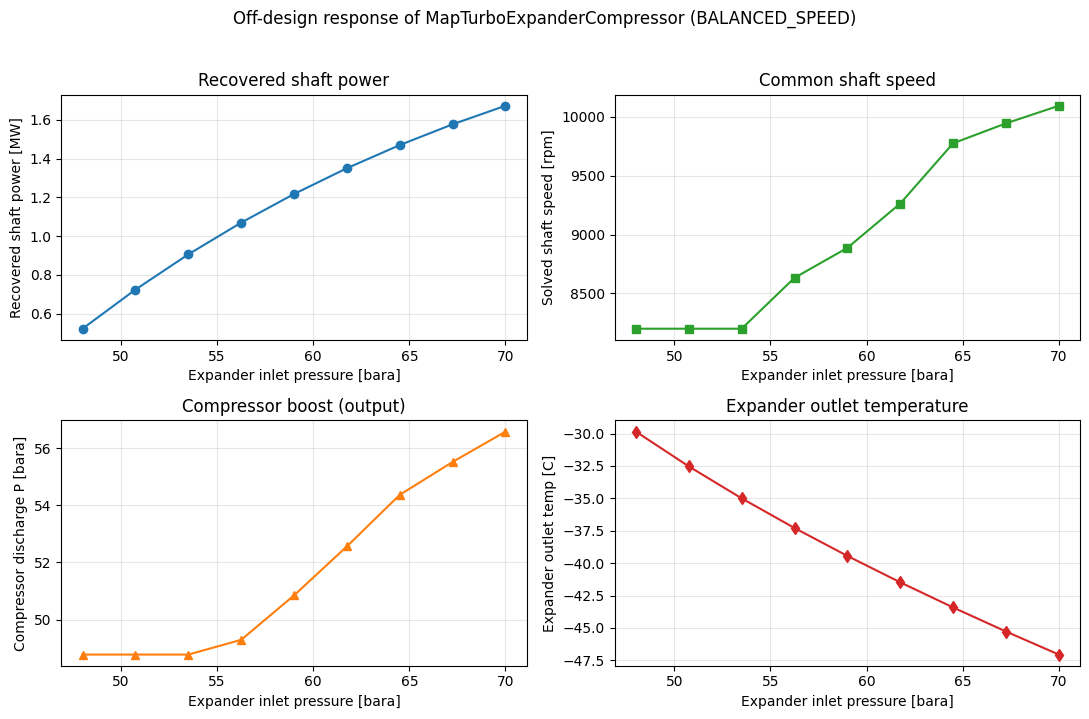

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].plot(sweep["P_in"], sweep["shaft_MW"], "o-", color="#1f77b4")
axes[0, 0].set_xlabel("Expander inlet pressure [bara]")
axes[0, 0].set_ylabel("Recovered shaft power [MW]")
axes[0, 0].set_title("Recovered shaft power")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(sweep["P_in"], sweep["speed"], "s-", color="#2ca02c")
axes[0, 1].set_xlabel("Expander inlet pressure [bara]")
axes[0, 1].set_ylabel("Solved shaft speed [rpm]")
axes[0, 1].set_title("Common shaft speed")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(sweep["P_in"], sweep["comp_P"], "^-", color="#ff7f0e")
axes[1, 0].set_xlabel("Expander inlet pressure [bara]")
axes[1, 0].set_ylabel("Compressor discharge P [bara]")
axes[1, 0].set_title("Compressor boost (output)")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(sweep["P_in"], sweep["exp_T"], "d-", color="#d62728")
axes[1, 1].set_xlabel("Expander inlet pressure [bara]")
axes[1, 1].set_ylabel("Expander outlet temp [C]")
axes[1, 1].set_title("Expander outlet temperature")
axes[1, 1].grid(alpha=0.3)

fig.suptitle("Off-design response of MapTurboExpanderCompressor (BALANCED_SPEED)", y=1.02)
plt.tight_layout()
plt.show()

## 10. Turboexpander turndown — feasibility as the inlet pressure falls

A turboexpander-compressor is a **self-powered** machine: the expander must supply all the shaft
power the brake compressor absorbs. The isentropic enthalpy drop available to a turbine scales
(for a near-ideal gas) as

$$\Delta h_{s} = c_p\,T_{1}\left[1-\left(\frac{P_2}{P_1}\right)^{\frac{\gamma-1}{\gamma}}\right]$$

so as the expander **inlet pressure $P_1$ falls towards the (fixed) outlet pressure $P_2$**, the
bracket — and therefore the recovered shaft power — collapses towards zero.

The brake compressor, by contrast, always has to deliver a finite head to move gas from its suction
to its discharge. Even at the **lowest speed line of its performance map** it absorbs a finite,
roughly constant power (the compressor feed here is unchanged during the sweep). The machine is
**feasible only while the available expander power exceeds this minimum compressor demand**. Below
that crossover the solver pegs the shaft at the minimum map speed (`speedLimited = True`, negative
power-balance residual): the compressor operating point has crossed its **surge line** and, in a
real unit, the anti-surge / recycle valve must open to keep the machine alive.

This is exactly the **turndown limit** described in the turboexpander literature
(Bloch & Soares, *Turboexpanders and Process Applications*, 2001; Agahi & Ershaghi, Mafi-Trench
expander-compressor performance papers) and is the physical meaning of the **recycle line** drawn on
the EC-OD™ performance maps.

In [13]:
# --- Constant compressor power demand at the map speed limits -------------------
# The compressor feed is fixed during the sweep, so its min/max-speed power demand
# is constant. These two horizontal lines bracket the feasible operating band.
demand_chart = CompressorChartKhader2015(compressor_feed.clone(), 0.9)
demand_chart.setCurves(to_java_1d(chart_conditions), to_java_1d(speed),
                       to_java_2d(flow), to_java_2d(head), to_java_2d(flow), to_java_2d(poly_eff))
min_speed_curve = demand_chart.getMinSpeedCurve()
max_speed_curve = demand_chart.getMaxSpeedCurve()


def compressor_demand_at_speed(spd):
    c = Compressor("demand", compressor_feed.clone())
    c.setUsePolytropicCalc(True)
    ch = CompressorChartKhader2015(c.getInletStream(), 0.9)
    ch.setCurves(to_java_1d(chart_conditions), to_java_1d(speed),
                 to_java_2d(flow), to_java_2d(head), to_java_2d(flow), to_java_2d(poly_eff))
    c.setCompressorChart(ch)
    c.getCompressorChart().setHeadUnit("kJ/kg")
    c.setSolveSpeed(False)
    c.setCalcPressureOut(True)
    c.setSpeed(spd)
    c.run()
    return c.getPower() / 1e6  # MW


demand_min_MW = compressor_demand_at_speed(min_speed_curve)
demand_max_MW = compressor_demand_at_speed(max_speed_curve)
print("Compressor min-speed (%.0f rpm) power demand: %.3f MW" % (min_speed_curve, demand_min_MW))
print("Compressor max-speed (%.0f rpm) power demand: %.3f MW" % (max_speed_curve, demand_max_MW))

Compressor min-speed (8200 rpm) power demand: 1.019 MW
Compressor max-speed (12913 rpm) power demand: 3.298 MW


In [14]:
# --- Fine inlet-pressure sweep towards the expander outlet pressure (42 bara) ----
P_OUT = 42.0  # expander discharge pressure [bara]
fine_P = np.linspace(60.95, P_OUT + 0.5, 40)

turndown = {"P_in": [], "avail_MW": [], "consumed_MW": [], "residual_MW": [],
            "speed": [], "speed_limited": [], "comp_P": [], "exp_T": [], "regime": []}

TOL_MW = 1.0e-3  # 1 kW residual tolerance

for p_in in fine_P:
    ef = Stream("ef", make_gas(-23.0, float(p_in)))
    ef.setFlowRate(200000.0, "kg/hr")
    ef.run()
    cf = Stream("cf", make_gas(17.0, 42.0))
    cf.setFlowRate(130000.0, "kg/hr")
    cf.run()

    m = MapTurboExpanderCompressor("turndown", ef, cf)
    m.setExpanderOutletPressure(P_OUT)
    m.setExpanderIsentropicEfficiency(0.85)
    m.setMechanicalEfficiency(0.98)
    ch = CompressorChartKhader2015(m.getCompressor().getInletStream(), 0.9)
    ch.setCurves(to_java_1d(chart_conditions), to_java_1d(speed),
                 to_java_2d(flow), to_java_2d(head), to_java_2d(flow), to_java_2d(poly_eff))
    m.getCompressor().setCompressorChart(ch)
    m.getCompressor().getCompressorChart().setHeadUnit("kJ/kg")
    m.getCompressor().setUsePolytropicCalc(True)
    m.setShaftMode(ShaftMode.BALANCED_SPEED)
    m.run(UUID.randomUUID())

    avail = m.getAvailableShaftPower() / 1e6
    consumed = m.getConsumedCompressorPower() / 1e6
    resid = m.getPowerBalanceResidual() / 1e6
    limited = bool(m.isSpeedLimited())

    if limited and resid < -TOL_MW:
        regime = "INFEASIBLE (under-power / surge)"
    elif limited and resid > TOL_MW:
        regime = "speed pegged at max"
    else:
        regime = "feasible (balanced)"

    turndown["P_in"].append(p_in)
    turndown["avail_MW"].append(avail)
    turndown["consumed_MW"].append(consumed)
    turndown["residual_MW"].append(resid)
    turndown["speed"].append(m.getShaftSpeed())
    turndown["speed_limited"].append(limited)
    turndown["comp_P"].append(m.getCompressorOutStream().getPressure("bara"))
    turndown["exp_T"].append(m.getExpanderOutStream().getTemperature("C"))
    turndown["regime"].append(regime)

print("Turndown sweep complete (%d points)." % len(fine_P))

Turndown sweep complete (40 points).


In [15]:
# --- Locate the minimum feasible inlet pressure ---------------------------------
import numpy as np

P_in_arr = np.array(turndown["P_in"])
feasible_mask = np.array([r == "feasible (balanced)" for r in turndown["regime"]])

if feasible_mask.any():
    P_min_feasible = P_in_arr[feasible_mask].min()
    P_max_feasible = P_in_arr[feasible_mask].max()
else:
    P_min_feasible = P_max_feasible = float("nan")

# First infeasible (under-power) pressure encountered as we step down
underpower_mask = np.array([r.startswith("INFEASIBLE") for r in turndown["regime"]])
P_first_infeasible = P_in_arr[underpower_mask].max() if underpower_mask.any() else float("nan")

print("Feasible inlet-pressure band : %.2f - %.2f bara" % (P_min_feasible, P_max_feasible))
print("Minimum feasible inlet P     : %.2f bara" % P_min_feasible)
print("Highest infeasible inlet P   : %.2f bara (machine cannot drive compressor)"
      % P_first_infeasible)
print("Expander pressure ratio at limit: %.2f" % (P_min_feasible / P_OUT))
print()
print("Pressure [bara] | Avail MW | Comp MW | Resid MW | Speed rpm | Regime")
for i in range(len(P_in_arr)):
    print("   %6.2f       |  %6.3f  | %6.3f  | %+7.3f | %8.0f | %s" % (
        turndown["P_in"][i], turndown["avail_MW"][i], turndown["consumed_MW"][i],
        turndown["residual_MW"][i], turndown["speed"][i], turndown["regime"][i]))

Feasible inlet-pressure band : 55.75 - 60.95 bara
Minimum feasible inlet P     : 55.75 bara
Highest infeasible inlet P   : 55.27 bara (machine cannot drive compressor)
Expander pressure ratio at limit: 1.33

Pressure [bara] | Avail MW | Comp MW | Resid MW | Speed rpm | Regime
    60.95       |   1.313  |  1.313  |  +0.000 |     9199 | feasible (balanced)
    60.48       |   1.290  |  1.290  |  -0.000 |     9160 | feasible (balanced)
    60.00       |   1.267  |  1.267  |  -0.000 |     9120 | feasible (balanced)
    59.53       |   1.244  |  1.244  |  +0.000 |     8934 | feasible (balanced)
    59.06       |   1.220  |  1.220  |  +0.000 |     8892 | feasible (balanced)
    58.58       |   1.196  |  1.196  |  -0.000 |     8850 | feasible (balanced)
    58.11       |   1.171  |  1.171  |  -0.000 |     8807 | feasible (balanced)
    57.64       |   1.146  |  1.146  |  -0.000 |     8764 | feasible (balanced)
    57.17       |   1.120  |  1.120  |  -0.000 |     8720 | feasible (balanced)
   

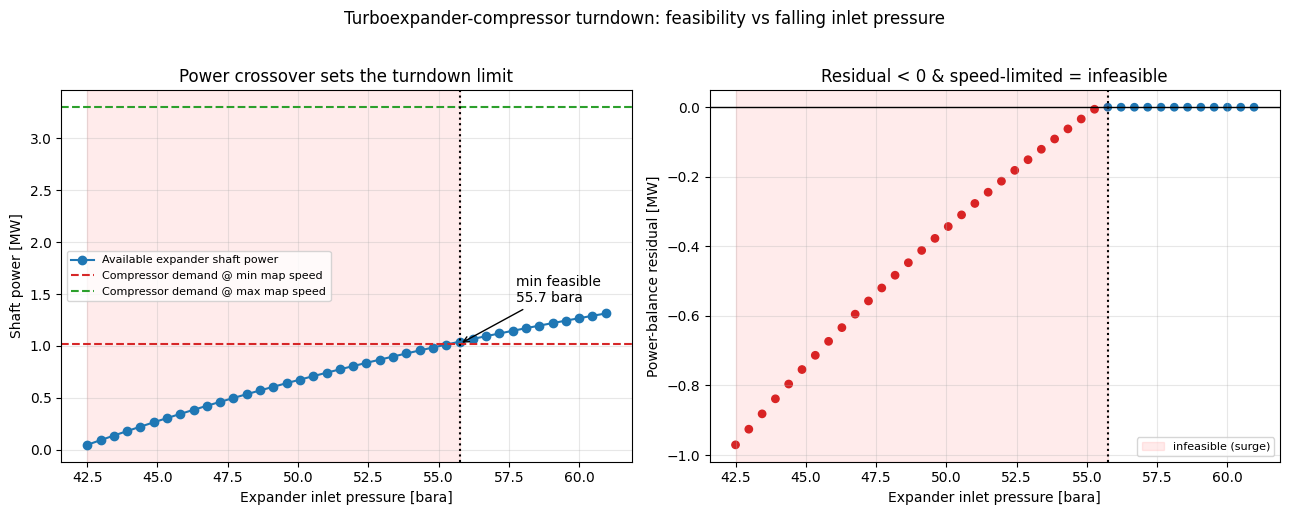

In [16]:
# --- Plot: power crossover and feasibility band ---------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: available expander power vs constant compressor demand limits
ax1.plot(turndown["P_in"], turndown["avail_MW"], "o-", color="#1f77b4",
         label="Available expander shaft power")
ax1.axhline(demand_min_MW, color="#d62728", ls="--",
            label="Compressor demand @ min map speed")
ax1.axhline(demand_max_MW, color="#2ca02c", ls="--",
            label="Compressor demand @ max map speed")
if np.isfinite(P_min_feasible):
    ax1.axvline(P_min_feasible, color="black", ls=":", lw=1.5)
    ax1.annotate("min feasible\n%.1f bara" % P_min_feasible,
                 xy=(P_min_feasible, demand_min_MW),
                 xytext=(P_min_feasible + 2, demand_min_MW + 0.4),
                 arrowprops=dict(arrowstyle="->"))
    ax1.axvspan(turndown["P_in"][-1], P_min_feasible, color="red", alpha=0.08)
ax1.set_xlabel("Expander inlet pressure [bara]")
ax1.set_ylabel("Shaft power [MW]")
ax1.set_title("Power crossover sets the turndown limit")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Right: power-balance residual; infeasible region shaded
colors = ["#d62728" if r.startswith("INFEASIBLE") else
          ("#ff7f0e" if r.endswith("max") else "#1f77b4") for r in turndown["regime"]]
ax2.scatter(turndown["P_in"], turndown["residual_MW"], c=colors, s=28)
ax2.axhline(0.0, color="black", lw=1)
if np.isfinite(P_min_feasible):
    ax2.axvline(P_min_feasible, color="black", ls=":", lw=1.5)
    ax2.axvspan(turndown["P_in"][-1], P_min_feasible, color="red", alpha=0.08,
                label="infeasible (surge)")
ax2.set_xlabel("Expander inlet pressure [bara]")
ax2.set_ylabel("Power-balance residual [MW]")
ax2.set_title("Residual < 0 & speed-limited = infeasible")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle("Turboexpander-compressor turndown: feasibility vs falling inlet pressure", y=1.02)
plt.tight_layout()
plt.show()

### Interpretation and link to the literature

- **Mechanism.** The recovered expander power falls monotonically as the inlet pressure approaches
  the discharge pressure, following the isentropic enthalpy-drop law above. The brake compressor's
  power demand at its lowest map speed is essentially constant (its feed is unchanged). The
  **crossover of these two curves is the minimum feasible inlet pressure** — the classic *turndown*
  or *minimum-power* limit of a companding machine.

- **What "infeasible" means here.** Below the crossover the solver cannot find an interior shaft
  speed: it pegs at the minimum map speed and reports a **negative power-balance residual** and
  `speedLimited = True`. Physically the compressor is being pushed to the **left of its surge
  line** — operation is only possible with the anti-surge / **recycle valve open**, which is drawn
  as the *recycle line* on the EC-OD™ performance maps.

- **Velocity-ratio (U/C) view.** Radial-inflow turbines have peak efficiency near a blade-to-spouting
  velocity ratio $U/C \approx 0.7$ (Whitfield & Baines, *Design of Radial Turbomachines*, 1990). As
  $P_1$ drops the spouting velocity $C$ collapses; to stay near optimum $U/C$ the shaft would have to
  slow down, but the compressor map imposes a **minimum usable speed**, so efficiency and head fall
  away and the unit reaches the surge-limited turndown point.

- **Operational practice.** Bloch & Soares (2001) and Agahi & Ershaghi document that real
  expander-compressor sets handle low-flow / low-pressure operation with **inlet guide vanes (IGV)**
  and **brake-compressor anti-surge recycle**; the curve-fit `TurboExpanderCompressor` model in this
  notebook exposes the IGV degree of freedom, while `MapTurboExpanderCompressor` reproduces the
  surge-limited turndown directly from the compressor map.

> **Takeaway:** for the gas and map used here, the machine remains self-sustaining down to roughly
> the *minimum feasible inlet pressure* reported above; below it the brake compressor would surge and
> the recycle valve must open — consistent with the turndown behaviour described in the turboexpander
> literature and represented by the EC-OD recycle line.

## 11. IGV throttling and anti-surge recycle — quantitative turndown extension

The previous section located the **turndown limit** as a single crossover point. Real machines push
that limit further with the two control handles called out in the literature
(Bloch & Soares, 2001; Agahi & Ershaghi):

1. **Expander inlet guide vanes (IGV)** — a variable nozzle area that throttles the expander flow and
   keeps the blade-to-spouting velocity ratio $U/C$ near its optimum ($\approx 0.7$) as throughput
   falls. The curve-fit `TurboExpanderCompressor` exposes this as a computed `IGVopening`.
2. **Brake-compressor anti-surge recycle** — a recycle / hot-gas-bypass valve that makes up the power
   deficit and keeps the brake compressor a safe margin away from its surge line when the shaft is
   forced to the edge of the map.

Below we quantify both effects and **fit closed-form curves** to the simulated behaviour so they can
be reused as quick screening correlations.

For a radial-inflow turbine the nozzle continuity relation ties the effective open area to the flow:

$$A_{\text{IGV}} \;\propto\; \frac{\dot m}{\rho\,C}\;=\;\frac{Q}{C},\qquad C=\sqrt{2\,\Delta h_s}$$

so a lower volumetric flow $Q$ at a roughly constant spouting velocity $C$ demands a smaller open
area — the vanes pinch closed.


In [17]:
# --- Part A: IGV opening vs expander throughput (TurboExpanderCompressor) --------
# Sweep the expander feed flow (throughput turndown) at the design inlet pressure and
# record the model-computed IGV opening, U/C ratio and expander efficiency.
igv_flows = np.linspace(200000.0, 150000.0, 11)  # kg/hr, 100% -> 75% (model valid range)
base_flow = 200000.0
igv = {"flow": [], "flow_frac": [], "opening": [], "uc": [], "eta_exp": [],
       "speed": [], "power_MW": []}

for w in igv_flows:
    ef = Stream("ef_igv", make_gas(-23.0, 60.95))
    ef.setFlowRate(float(w), "kg/hr")
    ef.run()
    cf = Stream("cf_igv", make_gas(17.0, 42.0))
    cf.setFlowRate(130000.0, "kg/hr")
    cf.run()

    t = TurboExpanderCompressor("igv_sweep", ef)
    t.setCompressorFeedStream(cf)
    t.setUCcurve(
        to_java_1d([0.99648, 0.75908, 0.98430, 0.88278, 0.95525, 1.0]),
        to_java_1d([0.98409, 0.79659, 0.99318, 0.93636, 0.99432, 1.0]))
    t.setQNEfficiencycurve(
        to_java_1d([0.5, 0.7, 0.85, 1.0, 1.2, 1.4, 1.6]),
        to_java_1d([0.88, 0.91, 0.95, 1.0, 0.97, 0.85, 0.6]))
    t.setQNHeadcurve(
        to_java_1d([0.5, 0.8, 1.0, 1.2, 1.4, 1.6]),
        to_java_1d([1.1, 1.05, 1.0, 0.9, 0.7, 0.4]))
    t.setImpellerDiameter(0.424)
    t.setDesignSpeed(6850.0)
    t.setExpanderDesignIsentropicEfficiency(0.88)
    t.setDesignUC(0.7)
    t.setDesignQn(0.03328)
    t.setExpanderOutPressure(42.0)
    t.setCompressorDesignPolytropicEfficiency(0.81)
    t.setCompressorDesignPolytropicHead(20.47)
    t.setMaximumIGVArea(1.637e4)
    t.run()

    igv["flow"].append(w)
    igv["flow_frac"].append(w / base_flow)
    igv["opening"].append(t.getIGVopening())
    igv["uc"].append(t.getUCratioexpander())
    igv["eta_exp"].append(t.getExpanderIsentropicEfficiency())
    igv["speed"].append(t.getSpeed())
    igv["power_MW"].append(t.getPowerExpander("MW"))

print("IGV throughput sweep complete (%d points)." % len(igv_flows))
for i in range(len(igv["flow"])):
    print("  flow %6.0f kg/hr (%3.0f%%) | IGV %.3f | U/C %.3f | eta_exp %.3f | speed %.0f rpm"
          % (igv["flow"][i], 100 * igv["flow_frac"][i], igv["opening"][i],
             igv["uc"][i], igv["eta_exp"][i], igv["speed"][i]))


IGV throughput sweep complete (11 points).
  flow 200000 kg/hr (100%) | IGV 0.258 | U/C 0.963 | eta_exp 0.876 | speed 7229 rpm
  flow 195000 kg/hr ( 98%) | IGV 0.252 | U/C 0.949 | eta_exp 0.872 | speed 7127 rpm
  flow 190000 kg/hr ( 95%) | IGV 0.246 | U/C 0.934 | eta_exp 0.867 | speed 7018 rpm
  flow 185000 kg/hr ( 92%) | IGV 0.239 | U/C 0.919 | eta_exp 0.859 | speed 6901 rpm
  flow 180000 kg/hr ( 90%) | IGV 0.233 | U/C 0.902 | eta_exp 0.850 | speed 6775 rpm
  flow 175000 kg/hr ( 88%) | IGV 0.226 | U/C 0.884 | eta_exp 0.838 | speed 6637 rpm
  flow 170000 kg/hr ( 85%) | IGV 0.220 | U/C 0.864 | eta_exp 0.822 | speed 6486 rpm
  flow 165000 kg/hr ( 82%) | IGV 0.213 | U/C 0.841 | eta_exp 0.800 | speed 6314 rpm
  flow 160000 kg/hr ( 80%) | IGV 0.207 | U/C 0.814 | eta_exp 0.771 | speed 6113 rpm
  flow 155000 kg/hr ( 78%) | IGV 0.200 | U/C 0.780 | eta_exp 0.728 | speed 5857 rpm
  flow 150000 kg/hr ( 75%) | IGV 0.194 | U/C 0.668 | eta_exp 0.534 | speed 5167 rpm


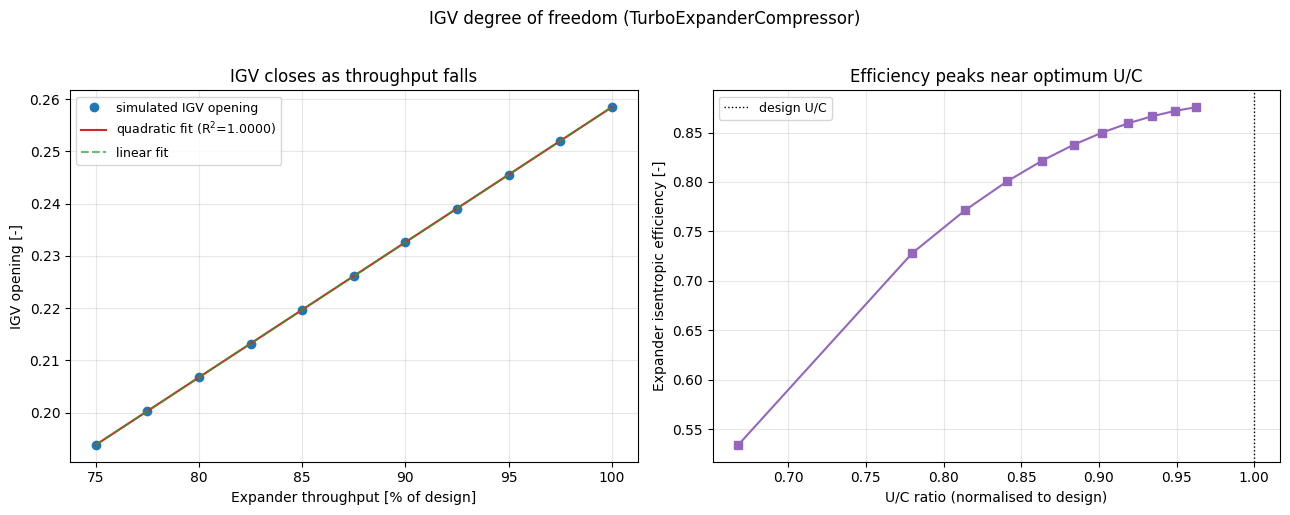

Quadratic IGV schedule: opening = 0.0000*f^2 + 0.2584*f + 0.0000   (f = flow fraction)
Linear    IGV schedule: opening = 0.2584*f + -0.0000


In [18]:
# --- Fit a closed-form IGV schedule: opening = f(flow fraction) ------------------
ff = np.array(igv["flow_frac"])
op = np.array(igv["opening"])

c1 = np.polyfit(ff, op, 1)            # linear fit
c2 = np.polyfit(ff, op, 2)            # quadratic fit
ff_fit = np.linspace(ff.min(), ff.max(), 100)
op_lin = np.polyval(c1, ff_fit)
op_quad = np.polyval(c2, ff_fit)
r2 = 1.0 - np.sum((op - np.polyval(c2, ff)) ** 2) / np.sum((op - op.mean()) ** 2)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))

axA.plot(100 * ff, op, "o", color="#1f77b4", label="simulated IGV opening")
axA.plot(100 * ff_fit, op_quad, "-", color="#d62728",
         label="quadratic fit (R$^2$=%.4f)" % r2)
axA.plot(100 * ff_fit, op_lin, "--", color="#2ca02c", alpha=0.7, label="linear fit")
axA.set_xlabel("Expander throughput [% of design]")
axA.set_ylabel("IGV opening [-]")
axA.set_title("IGV closes as throughput falls")
axA.legend(fontsize=9)
axA.grid(alpha=0.3)

axB.plot(igv["uc"], igv["eta_exp"], "s-", color="#9467bd")
axB.axvline(1.0, color="black", ls=":", lw=1, label="design U/C")
axB.set_xlabel("U/C ratio (normalised to design)")
axB.set_ylabel("Expander isentropic efficiency [-]")
axB.set_title("Efficiency peaks near optimum U/C")
axB.legend(fontsize=9)
axB.grid(alpha=0.3)

fig.suptitle("IGV degree of freedom (TurboExpanderCompressor)", y=1.02)
plt.tight_layout()
plt.show()

print("Quadratic IGV schedule: opening = %.4f*f^2 + %.4f*f + %.4f   (f = flow fraction)"
      % (c2[0], c2[1], c2[2]))
print("Linear    IGV schedule: opening = %.4f*f + %.4f" % (c1[0], c1[1]))


**Reading the IGV result.** As the expander throughput is reduced the model pinches the inlet guide
vanes closed (lower `IGVopening`), and the relationship is essentially **linear** — a direct
confirmation of the nozzle continuity law $A_{\text{IGV}}\propto Q/C$ (the quadratic term is
negligible, so the linear and quadratic fits overlie each other with $R^2\approx1$). Closing the
vanes raises the spouting velocity for the reduced flow, which keeps the blade-speed ratio $U/C$
— and therefore the expander efficiency (right panel) — near its optimum down to about 80% load.
Below ~75% load the single-shaft machine can no longer hold $U/C$ and the efficiency rolls off
sharply; this is exactly the region where IGV throttling must be supplemented by speed change or
recycle. The fitted schedule gives a compact feed-forward setpoint for the vane actuator.


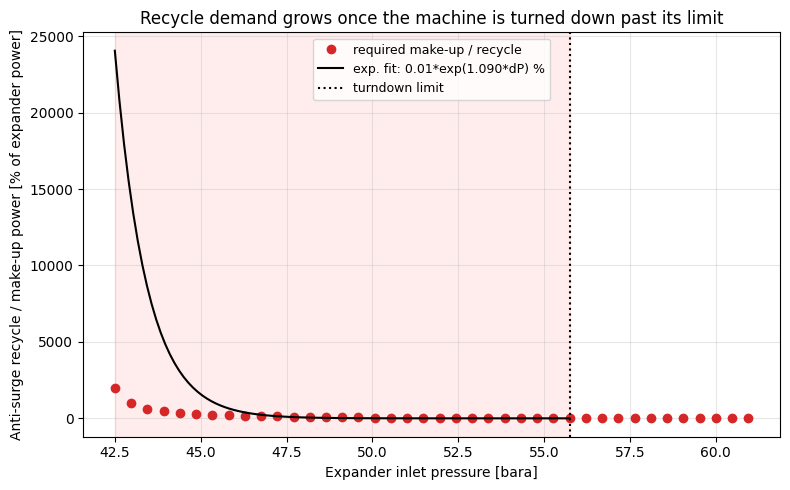

Turndown limit (min feasible inlet P): 55.75 bara
Recycle correlation: make-up[%] = 0.013 * exp(1.0899 * (P_lim - P_in))
   0.5 bar below limit -> 0.0 % recycle/make-up power
   1.0 bar below limit -> 0.0 % recycle/make-up power
   2.0 bar below limit -> 0.1 % recycle/make-up power
   4.0 bar below limit -> 1.0 % recycle/make-up power


In [19]:
# --- Part B: anti-surge recycle / make-up power below the turndown limit ---------
# Reuse the fine turndown sweep. Below the turndown limit the expander is under-powered:
# the power deficit must be made up by an anti-surge recycle / hot-gas bypass action.
# Fractional make-up = power deficit / available expander power.
P_arr = np.array(turndown["P_in"])
avail = np.array(turndown["avail_MW"])
consumed = np.array(turndown["consumed_MW"])
deficit = consumed - avail                                  # MW (positive => infeasible)
makeup_frac = np.clip(deficit / np.maximum(avail, 1e-6), 0.0, None) * 100.0   # %

# Fit an exponential to the infeasible branch: makeup% = a*exp(b*(P_lim - P_in))
infeasible = makeup_frac > 1e-6
a = b = np.nan
if infeasible.sum() >= 3:
    dP = P_min_feasible - P_arr[infeasible]                 # pressure shortfall below limit
    y = makeup_frac[infeasible]
    b, lnA = np.polyfit(dP, np.log(y), 1)                   # ln(y) = ln(a) + b*dP
    a = np.exp(lnA)
    dP_fit = np.linspace(0.0, dP.max(), 100)
    y_fit = a * np.exp(b * dP_fit)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(P_arr, makeup_frac, "o", color="#d62728", label="required make-up / recycle")
if np.isfinite(a):
    ax.plot(P_min_feasible - dP_fit, y_fit, "-", color="black",
            label="exp. fit: %.2f*exp(%.3f*dP) %%" % (a, b))
ax.axvline(P_min_feasible, color="black", ls=":", lw=1.5, label="turndown limit")
ax.axvspan(P_arr.min(), P_min_feasible, color="red", alpha=0.07)
ax.set_xlabel("Expander inlet pressure [bara]")
ax.set_ylabel("Anti-surge recycle / make-up power [% of expander power]")
ax.set_title("Recycle demand grows once the machine is turned down past its limit")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Turndown limit (min feasible inlet P): %.2f bara" % P_min_feasible)
if np.isfinite(a):
    print("Recycle correlation: make-up[%%] = %.3f * exp(%.4f * (P_lim - P_in))" % (a, b))
    for dp in [0.5, 1.0, 2.0, 4.0]:
        print("   %.1f bar below limit -> %.1f %% recycle/make-up power"
              % (dp, a * np.exp(b * dp)))


**Reading the recycle result.** Above the turndown limit the machine is self-balancing and no recycle
is needed (0 %). Once the inlet pressure drops below the limit the expander can no longer supply the
brake-compressor power at the minimum map speed; the **power deficit grows roughly exponentially**
with the pressure shortfall. In a real unit this deficit is absorbed by opening the
**anti-surge / hot-gas-bypass recycle** on the brake compressor (keeping it off its surge line) while
a Joule-Thomson / expander-bypass valve handles the remaining duty — the *recycle line* drawn on the
EC-OD™ performance maps.

Together the two fitted curves summarise the operating strategy described by Bloch & Soares (2001)
and Agahi & Ershaghi:

- **IGV schedule** (Part A) extends the *efficient* turndown range by keeping $U/C$ near optimum.
- **Recycle correlation** (Part B) quantifies the make-up power the anti-surge system must supply
  once the machine is pushed past its self-sustaining limit.

> **Caveat.** These are screening correlations fitted to a single gas, map and design point. The
> coefficients should be refitted for a specific machine, but the *functional form* — IGV closing
> roughly linearly with flow, recycle demand rising exponentially below the turndown limit — is
> general.


## 12. Summary — which model to use| Need | Use ||------|-----|| Quick power / outlet T for a turbine | **`Expander`** || Compressor on a known map at fixed/known speed | **`Compressor` + `CompressorChart`** || Compressor map valid across changing gas composition | **`CompressorChartKhader2015`** || Integrated machine matching EC-OD UI variables (IGV, U/C, % Design Q/N) | **`TurboExpanderCompressor`** || Integrated machine reusing a real compressor map + rigorous shaft power balance | **`MapTurboExpanderCompressor`** |### Relationship to EC-OD™Both integrated models reproduce the core of the Atlas Copco Mafi-Trench / River City Engineering EC-ODrating concept — a **single-shaft turboexpander-compressor solved by power balance**:- `TurboExpanderCompressor` mirrors the EC-OD *user variables* (IGV position, U/C ratio, % Design Q/N) via  explicit correction curves.- `MapTurboExpanderCompressor` mirrors the EC-OD *rigorous map method*, reusing NeqSim's  composition-aware compressor performance map and a clean common-shaft power balance.Unlike EC-OD, both are open-source, scriptable in Python/Java, and embeddable in larger NeqSim flowsheets.